# Probability and Statistics

<div style="display: flex; justify-content: center; ">
     <img src="./wimlds.png" style="width: 20%; height: 7em"/>
       <img src="./aims.jpeg" style="width: 20%; height: 7em"/>

</div>


© WiMLDS Accra 2025. Apache License 2.0.

In [18]:
from scipy.stats import bernoulli, binom, geom, nbinom
import numpy as np
import statistics
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [3]:
#Bernoulli Distribution
p=1/6
bernoulli(p).var()

np.float64(0.1388888888888889)

In [4]:
bernoulli.pmf(2,p)

np.float64(0.0)

In [5]:
# Binomial distribution
# setting the values
# of n and p
n = 3
p = 1/6
r=np.arange(4)
binom.pmf(r,n,p)

array([0.5787037 , 0.34722222, 0.06944444, 0.00462963])

In [6]:
# Define the probability of success
p = 1/6

# Create a Geometric random variable with the specified probability
rv = geom(p)

# Define the event of interest (e.g., number of trials until the first success)
num_trials = 5

# Calculate the probability of the event occurring
probability = rv.pmf(num_trials)

print("Probability of the event occurring after {} trials:".format(num_trials), probability)


Probability of the event occurring after 5 trials: 0.08037551440329219


In [19]:
# Define the parameters: number of failures (k) and success probability (p)
k = 6  # Number of failures
p = 0.3  # Probability of success in each trial

# Create a negative binomial random variable with the specified parameters
rv = nbinom(k, p)

# Define the number of successes (r) for which you want to calculate the probability
num_successes = 11

# Calculate the probability of observing the specified number of successes
probability = rv.pmf(num_successes)

print("Probability of {} successes after {} failures:".format(num_successes, k), probability)


Probability of 11 successes after 6 failures: 0.06296346182586099


In [9]:
# Mean calculation manually
data_1 = [1,3,5,5,3]
total = 0
for i in range(len(data_1)):
    total += data_1[i]
average = total/(len(data_1))
average

3.4

In [42]:
# Calculating mean using built-in function
statistics.mean(data_1)

3.4

In [43]:
#Mode calculations-First approach#
data_2 = [1, 3, 5, 5, 3, 8, 8, 8]

# Create a dictionary to store the count of each element
freq_dict = {}
for num in data_2:
    if num in freq_dict:
        freq_dict[num] += 1
    else:
        freq_dict[num] = 1

# Find the mode(s) by finding the element(s) with the maximum frequency
max_freq = max(freq_dict.values())
modes = [num for num, freq in freq_dict.items() if freq == max_freq]

# Print the mode(s)
print("Mode(s):", modes)


Mode(s): [8]


In [12]:
#Mode calculations - Built-in Function
data_3 = [1, 3, 5, 5, 3,8,8,8,9]
data_3_mode = statistics.mode(data_3)

In [45]:
#Median calculations-First approach#

def find_median(data):
    # Sort the data
    sorted_data = sorted(data)

    # Calculate the length of the data
    n = len(sorted_data)

    # Check if the number of elements is odd or even
    if n % 2 == 1:
        # If the number of elements is odd, return the middle element
        median_index = n // 2
        median = sorted_data[median_index]
    else:
        # If the number of elements is even, return the average of the two middle elements
        median_index1 = n // 2 - 1
        median_index2 = n // 2
        median = (sorted_data[median_index1] + sorted_data[median_index2]) / 2

    return median

# Example usage
data = [1, 3, 5, 5, 3, 8, 8, 8]
median_value = find_median(data)
print("Median:", median_value)


Median: 5.0


In [46]:
statistics.median(data_3)

5

## Exploratory Data Analysis and Visualisations

### Online Food Order Dataset
#### Description:
The dataset contains information collected from an online food ordering platform over a period of time. It encompasses various attributes related to Occupation, Family Size, Feedback etc..

Attributes:

Demographic Information:

Age: Age of the customer.<br />
Gender: Gender of the customer. <br />
Marital Status: Marital status of the customer. <br />
Occupation: Occupation of the customer. <br />
Monthly Income: Monthly income of the customer. <br />
Educational Qualifications: Educational qualifications of the customer. <br />
Family Size: Number of individuals in the customer's family. <br />
Location Information:<br />
Latitude: Latitude of the customer's location.<br />
Longitude: Longitude of the customer's location. <br />
Pin Code: Pin code of the customer's location.<br />
Order Details:<br />
Output: Current status of the order (e.g., pending, confirmed, delivered).<br />
Feedback: Feedback provided by the customer after receiving the order.

In [13]:
## Loading the dataset
data = pd.read_csv('./onlinefoods.csv')

In [16]:
## Show First 10 rows
data.head(10)

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes
5,27,Female,Married,Employee,More than 50000,Post Graduate,2,12.9299,77.6848,560103,Yes,Positive,Yes
6,22,Male,Single,Student,No Income,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
7,24,Female,Single,Student,No Income,Post Graduate,3,12.9828,77.6131,560042,Yes,Positive,Yes
8,23,Female,Single,Student,No Income,Post Graduate,2,12.9766,77.5993,560001,Yes,Positive,Yes
9,23,Female,Single,Student,No Income,Post Graduate,4,12.9854,77.7081,560048,Yes,Positive,Yes


In [54]:
# Size of dataset
data.shape

(388, 13)

In [55]:
# Information about columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   latitude                    388 non-null    float64
 8   longitude                   388 non-null    float64
 9   Pin code                    388 non-null    int64  
 10  Output                      388 non-null    object 
 11  Feedback                    388 non-null    object 
 12  Unnamed: 12                 388 non-null    object 
dtypes: float64(2), int64(3), object(8)


In [57]:
# Summary statistics rounded to two decimal places
data.describe().round(2)

,Age,Family size,latitude,longitude,Pin code
count,388.00,388.00,388.00,388.00,388.00
mean,24.63,3.28,12.97,77.60,560040.11
std,2.98,1.35,0.04,0.05,31.40
min,18.00,1.00,12.87,77.48,560001.00
25%,23.00,2.00,12.94,77.57,560010.75
50%,24.00,3.00,12.98,77.59,560033.50
75%,26.00,4.00,13.00,77.63,560068.00
max,33.00,6.00,13.10,77.76,560109.00


In [24]:
data.columns

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'latitude', 'longitude',
       'Pin code', 'Output', 'Feedback', 'Unnamed: 12'],
      dtype='object')

In [25]:
data = data.drop(['Unnamed: 12'], axis = 1)
data.columns

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'latitude', 'longitude',
       'Pin code', 'Output', 'Feedback'],
      dtype='object')

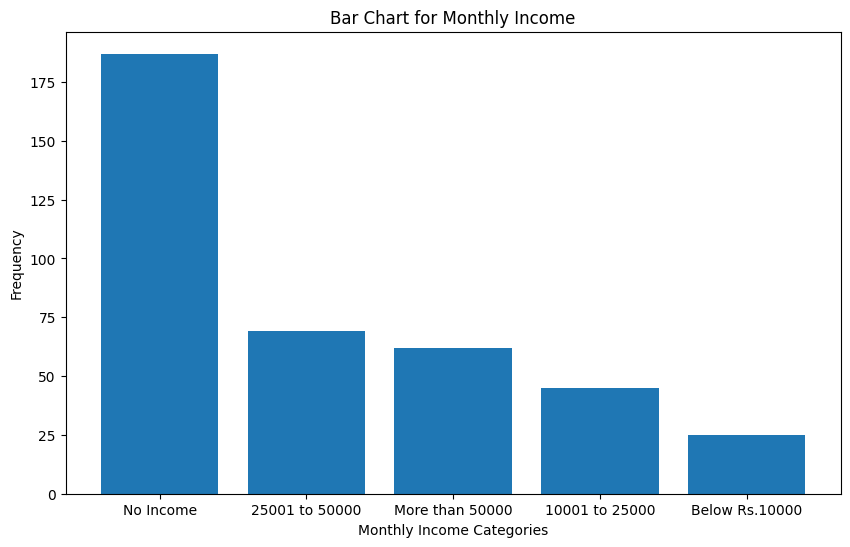

In [22]:
Inc_count = data['Monthly Income'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(Inc_count.index, height=Inc_count.values)
plt.xlabel('Monthly Income Categories')
plt.ylabel('Frequency')
plt.title('Bar Chart for Monthly Income')
plt.show()

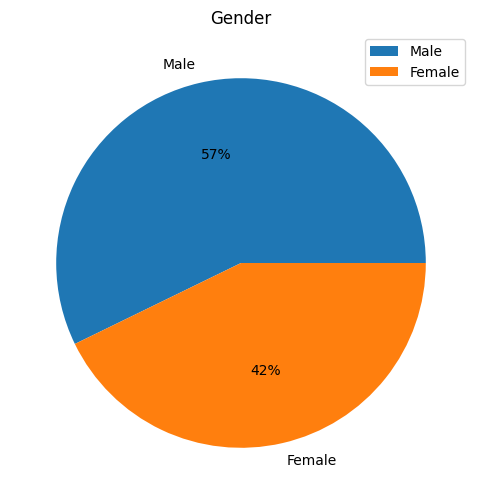

In [17]:
Gen_Count = data['Gender'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(Gen_Count, labels=Gen_Count.index, autopct='%d%%')
plt.title('Gender')

# Add legend
plt.legend(Gen_Count.index, loc='upper right')

plt.show()


In [ ]:
data['Age'].max()

33

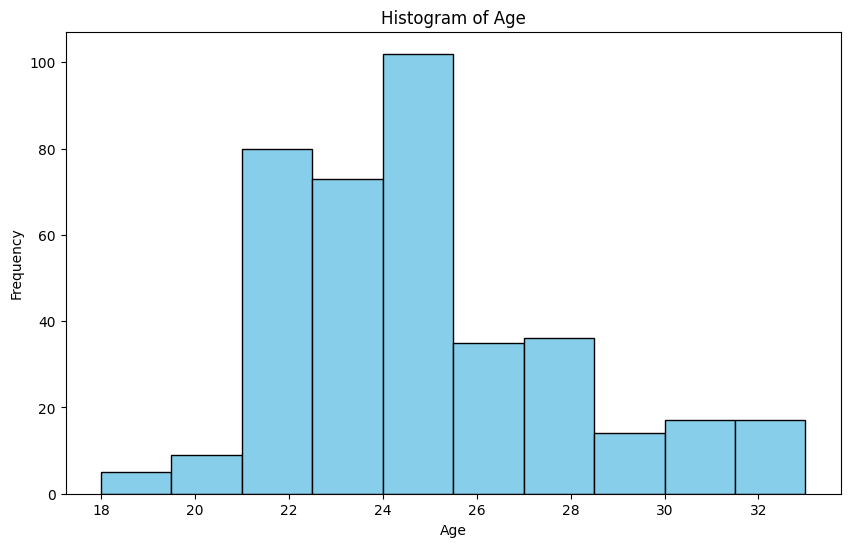

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(data['Age'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Histogram of Age')
plt.grid(False)
plt.show()


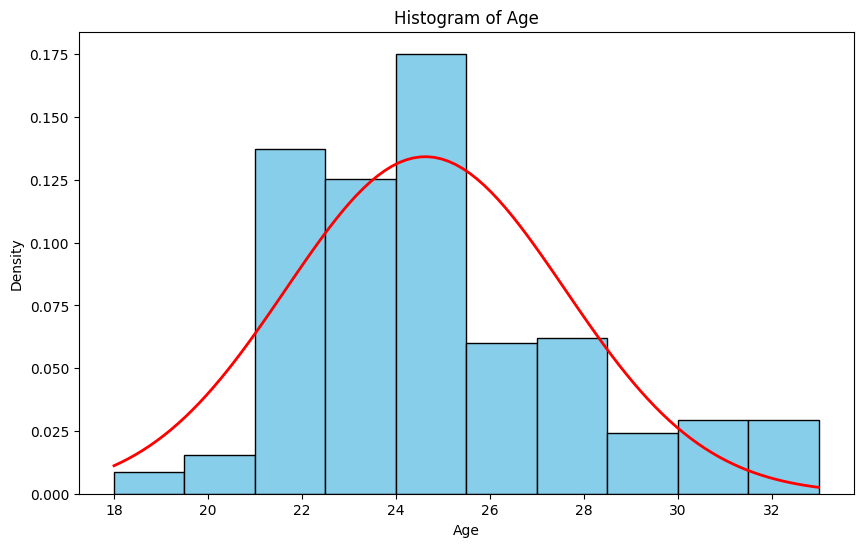

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(data['Age'], bins=10, density=True, color='skyblue', edgecolor='black')

# Plotting a curve
mu, sigma = np.mean(data['Age']), np.std(data['Age'])
x = np.linspace(data['Age'].min(), data['Age'].max(), 100)
plt.plot(x, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (x - mu)**2 / (2 * sigma**2) ), color='red', linestyle='-', linewidth=2)

plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Histogram of Age')
plt.grid(False)
plt.show()

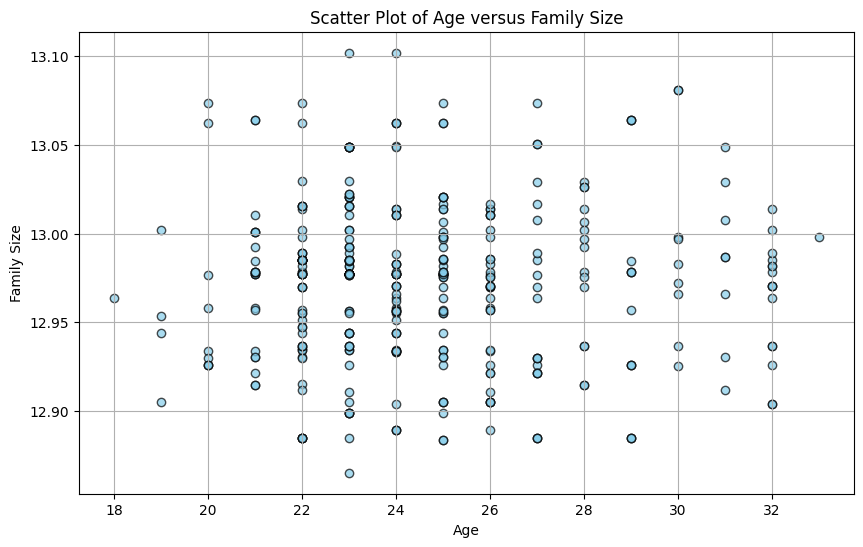

In [ ]:
# Increase figure size for better visibility
plt.figure(figsize=(10, 6))

# Plot scatter plot with improved aesthetics
plt.scatter(data['Age'], data['latitude'], color='skyblue', alpha=0.7, edgecolor='black')

# Add labels and title
plt.title('Scatter Plot of Age versus Family Size')
plt.xlabel('Age')
plt.ylabel('Family Size')

# Add grid lines for better visualization of data points
plt.grid(True)

In [ ]:
# Calculate correlation coefficient
correlation = data['Age'].corr(data['Family size'])

# Print the correlation coefficient
print("Correlation between Age and Family size:", correlation)

Correlation between Age and Family size: 0.16998151161738512


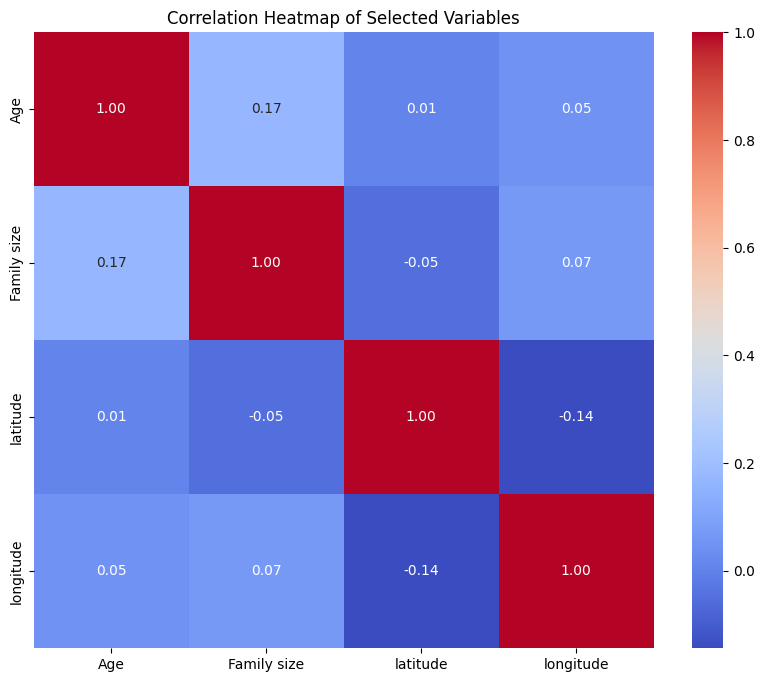

In [ ]:
# Select the variables of interest
selected_variables = ['Age', 'Monthly Income', 'Family size', 'latitude', 'longitude']

# Create a subset DataFrame with the selected variables
subset_data = data[selected_variables]

# Compute the correlation matrix
correlation_matrix = subset_data.corr(numeric_only=True)

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Selected Variables')
plt.show()

---
# Congrats! That's it for this tutorial.

---


---
*This notebook was originally created for the [Accra WiMLDS chapter ](https://www.linkedin.com/company/98583062/admin/feed/posts/) Mathematics for ML & Data Science course 2025 and is published under [MIT license](https://choosealicense.com/licenses/mit/).*